# Project 1

# Author: Gianfranco Cisneros PID: 6287481

# 0. Imports and Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
sns.set_style('whitegrid')

# 1. Data Exploration & Preprocessing


## 1.1 Exploratory Data Analysis


The code below will print the data and display the statistics. In addition, it will explore the data, attempting to identify any errors. These errors are then printed.

Dataset Shape:
(326, 8)
Dataset Types

Data Types and Non-Null Counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   student_id       326 non-null    int64  
 1   hours_studied    310 non-null    float64
 2   sleep_hours      310 non-null    float64
 3   attendance_rate  310 non-null    float64
 4   prev_exam_score  310 non-null    float64
 5   lucky_number     326 non-null    int64  
 6   exam_score       309 non-null    float64
 7   passed           326 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 20.5 KB
None

Summary Statistics


,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number,exam_score,passed
count,326.000000,310.000000,310.000000,310.000000,310.000000,326.000000,309.000000,326.000000
mean,1194.420245,7.656645,7.496258,56.055968,57.214161,50.328221,64.856084,0.579755
std,264.490578,4.547264,2.596727,28.806831,16.763007,29.232115,19.349312,0.494357
min,1001.000000,-5.000000,3.100000,-10.000000,20.070000,1.000000,-20.000000,0.000000
25%,1082.250000,3.980000,5.270000,31.087500,43.232500,26.000000,50.960000,0.000000
50%,1163.500000,8.005000,7.540000,57.255000,55.430000,50.000000,66.340000,1.000000
75%,1244.750000,11.425000,9.760000,79.035000,71.507500,77.000000,79.700000,1.000000
max,3006.000000,30.000000,12.000000,200.000000,94.270000,99.000000,150.000000,1.000000



Missing Values
student_id          0
hours_studied      16
sleep_hours        16
attendance_rate    16
prev_exam_score    16
lucky_number        0
exam_score         17
passed              0
dtype: int64

Impossible Values
Impossible values for hours_studied:
     student_id  hours_studied  sleep_hours  attendance_rate  prev_exam_score  \
38         1243           -5.0        11.73            34.37            46.42   
56         3005           -3.0        11.55            18.95            71.56   
117        1067           -5.0         6.22            10.99              NaN   
316        1255           -3.0        11.55            18.95            71.56   

     lucky_number  exam_score  passed  
38             87       49.93       0  
56             65       85.38       1  
117            55       31.70       0  
316            65       85.38       1  

Impossible values for attendance_rate:
     student_id  hours_studied  sleep_hours  attendance_rate  prev_exam_score  \
72         1

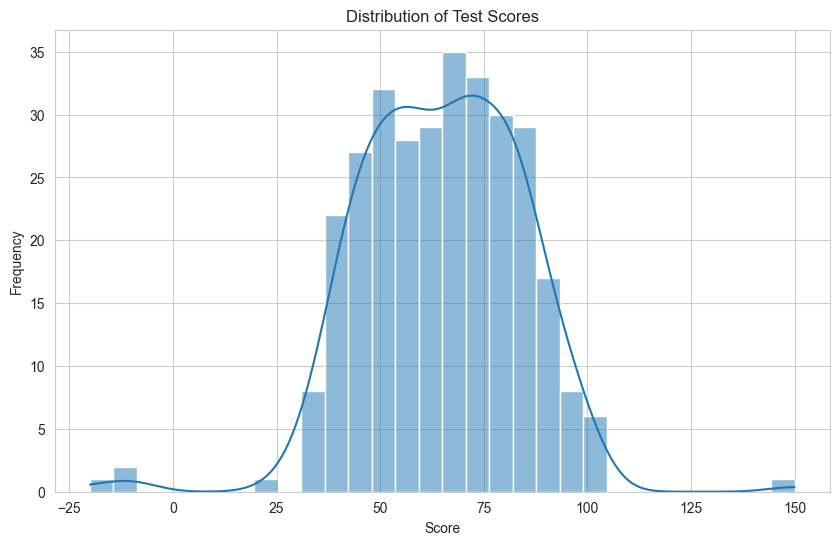

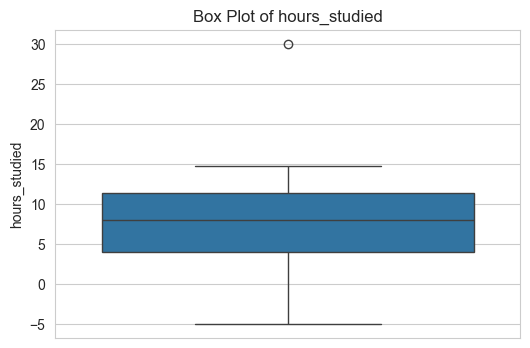

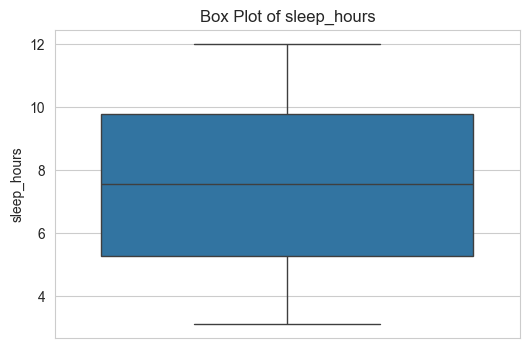

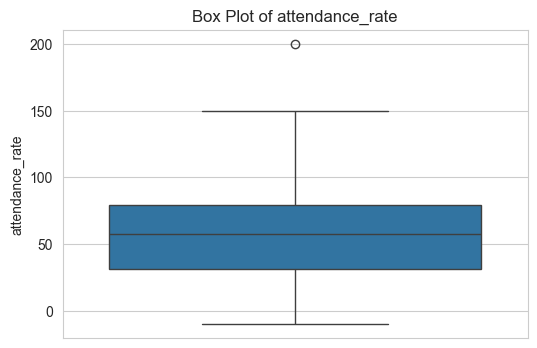

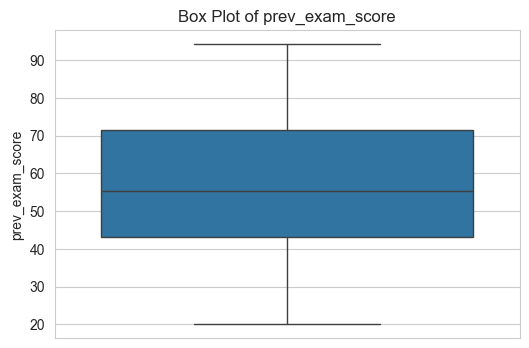

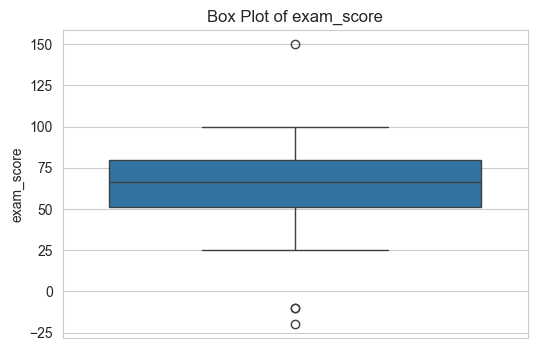

In [2]:
train = pd.read_csv('train.csv')

print("Dataset Shape:")
print(train.shape)
print("Dataset Types")

print("\nData Types and Non-Null Counts")
print(train.info())

print("\nSummary Statistics")
display(train.describe())

print("\nMissing Values")
print(train.isnull().sum())

print("\nImpossible Values")
print("Impossible values for hours_studied:")
print(train[train['hours_studied'] < 0])
print("\nImpossible values for attendance_rate:")
print(train[(train['attendance_rate'] < 0) | (train['attendance_rate'] > 100)])

      

#Visualization
plt.figure(figsize=(10, 6))
sns.histplot(train['exam_score'], bins=30, kde=True)
plt.title('Distribution of Test Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

#Box Plots
features = ['hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score', 'exam_score']
for i, col in enumerate(features):
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=train[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()




## 1.2 Data Cleaning


The code below the will clean the errors identified in the previous subsection. 

In [3]:
initial_row_count = len(train)
print("\nRow Counts Before Cleaning:")
print(train.count())

# Drops duplicates
train = train.drop_duplicates()
print("\nRow Counts After Removing Duplicates:")
print(train.count())

# Drops rows with missing values
train = train.dropna()
print("\nRow Counts After Removing Missing Values:")
print(train.count())

#Drops rows with impossible values
train = train[(train['hours_studied'] >= 0) & (train['attendance_rate'] >= 0) & (train['attendance_rate'] <= 100) & (train['exam_score'] >= 0) & (train['exam_score'] <= 100)]
print("\nRow Counts After Removing Impossible Values:")
print(train.count())
final_row_count = len(train)
print("Row Counts After Cleaning:")
print(train.count())
print(f"\nTotal Rows Removed: {initial_row_count - final_row_count}")

# Drops outliers in hours_studied
train = train[train['hours_studied'] <= 20]
print("\nRow Counts After Removing Outliers in hours_studied:")




Row Counts Before Cleaning:
student_id         326
hours_studied      310
sleep_hours        310
attendance_rate    310
prev_exam_score    310
lucky_number       326
exam_score         309
passed             326
dtype: int64

Row Counts After Removing Duplicates:
student_id         326
hours_studied      310
sleep_hours        310
attendance_rate    310
prev_exam_score    310
lucky_number       326
exam_score         309
passed             326
dtype: int64

Row Counts After Removing Missing Values:
student_id         254
hours_studied      254
sleep_hours        254
attendance_rate    254
prev_exam_score    254
lucky_number       254
exam_score         254
passed             254
dtype: int64

Row Counts After Removing Impossible Values:
student_id         246
hours_studied      246
sleep_hours        246
attendance_rate    246
prev_exam_score    246
lucky_number       246
exam_score         246
passed             246
dtype: int64
Row Counts After Cleaning:
student_id         246
hours

Explanation:
The way that I cleaned the data was simply dropping rows that had impossible values, duplicates or missing data. Since we had a considerably large dataset to train the model off of, I believe that dropping these rows would produce a more accurate model. Attempting to replace the impossible and incomplete data using data imputation could have adverse effects, such as skewing the data. This possibility would had trained a model that would have been less accurate. 

## 1.3 Feature Selection


The code below will print a correlation matrix between all the features. In addition, it will select the features for the model as well.

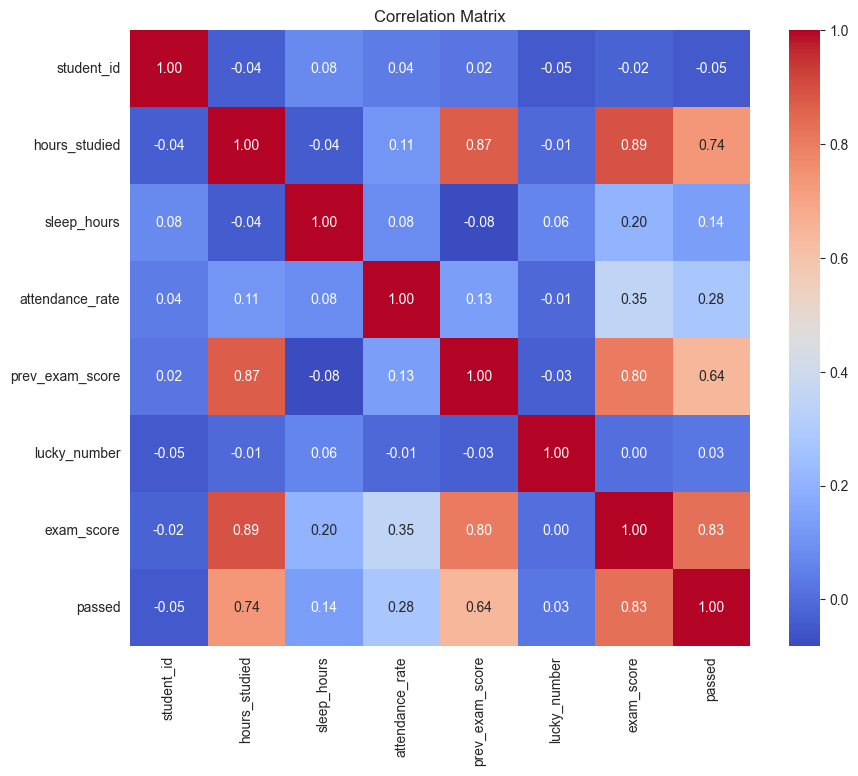


Selected Features for Modeling:
['hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score']


In [4]:
correlation_matrix = train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

selected_features = ['hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score']

x = train[selected_features]
y = train['exam_score']

print("\nSelected Features for Modeling:")
print(selected_features)


Explanation:
The reasoning behind the selected features are due to their positive correlation with exam_score. The 'hours_studied', 'sleep_hours', 'attendance_rate', and 'prev_exam_score', all have a positive correlation with the student's exam score. In contrast, 'lucky_number' and 'student_id' had little to no correlation with the respective student's exam score. Therefore, these features were dropped, and the remaining features will be used to train the model. In addition, the outler within the 'hours_studied' column was dropped, following the information within the class lecture, which says to drop any outliers. 

## 1.4 Data Normalization


In [5]:
print("\nFeatures Before Normalization:")
print("\nMean before Normalization:")
before_mean = train[selected_features].mean()
print(before_mean)
print("\nStandard Deviation before Normalization:")
before_std = train[selected_features].std()
print(before_std)



train_z_score = (train[selected_features] - before_mean) / before_std
l2_norm = np.linalg.norm(train_z_score, axis=1, keepdims=True)
train_l2_normalized = train[selected_features] / l2_norm

print("\nFeatures After Z-Score Normalization:")
print(train_z_score)
print("\nFeatures After L2 Normalization:")
print(train_l2_normalized)




Features Before Normalization:

Mean before Normalization:
hours_studied       7.666531
sleep_hours         7.401673
attendance_rate    56.146490
prev_exam_score    57.987755
dtype: float64

Standard Deviation before Normalization:
hours_studied       4.067598
sleep_hours         2.622319
attendance_rate    27.359693
prev_exam_score    16.226459
dtype: float64

Features After Z-Score Normalization:
     hours_studied  sleep_hours  attendance_rate  prev_exam_score
0         0.072148     1.368379        -0.545199         0.542462
2         1.598848     0.960343        -1.121960         1.898273
3         0.723638    -0.835777        -0.901198        -0.222338
4        -0.129445    -0.824336        -0.584308         0.007534
5        -0.839938     1.112880        -1.197619        -0.393047
..             ...          ...              ...              ...
319      -1.402924    -1.297200         0.342603        -1.170172
320      -1.189038     0.689591        -0.076627        -1.719276
321

Discussion:
Data normalization is important as it adjusts the values of all the features to be on the same scale. Thus, it is much easier to train the model. In addition, 

# 2. Linear Regression


## 2.1 NumPy Implementation


The code below will implement a linear regression model using the NumPy library from scratch. It will also print the final training and test MSE.


Final Weights:
[13.00332685  3.93728771  3.97463836  2.41519271]

Final Bias:
65.03138764565634


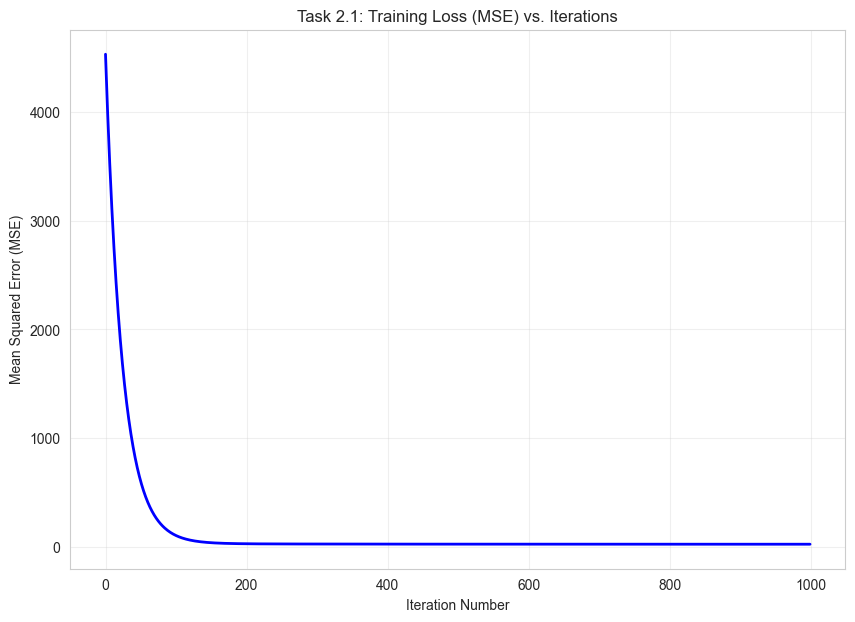


Final Train MSE: 26.3367
Final Test MSE: 26.2191


In [6]:
weights = np.zeros(train_z_score.shape[1])
bias = 0.0
learning_rate = 0.01
num_iterations = 1000
loss_history = []

# Loads testing data
test = pd.read_csv('test.csv')
x_test = test[selected_features]
y_test = test['exam_score']

# Normalizes test data using the mean and std from the training data
x_test_normalized = (x_test - before_mean) / before_std


for i in range(num_iterations):
    # Calculate predictions
    y_hat = np.dot(train_z_score.values, weights) + bias

    # Calculate error and loss
    error = y_hat - y.values
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Calculate gradients and update weights and bias
    gradient_1 = (2 / len(y.values)) * np.dot(train_z_score.values.T, error)
    gradient_2 = (2 / len(y.values)) * np.sum(error)

    weights -= learning_rate * gradient_1
    bias -= learning_rate * gradient_2

print("\nFinal Weights:")
print(weights)
print("\nFinal Bias:")
print(bias)

#Plot loss curve
plt.figure(figsize=(10, 7))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('Task 2.1: Training Loss (MSE) vs. Iterations')
plt.xlabel('Iteration Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, alpha=0.3)
plt.show()

# Print Train and Test MSE
train_mse = loss_history[-1]
# Makes prediction on test set
y_test_pred = np.dot(x_test_normalized.values, weights) + bias
test_mse = np.mean((y_test_pred - y_test.values) ** 2)
print(f"\nFinal Train MSE: {train_mse:.4f}")
print(f"Final Test MSE: {test_mse:.4f}")


## 2.2 PyTorch Verification



Final Weights from PyTorch Model:
[[13.029625   3.9359598  3.9754703  2.3886828]]

Final Bias from PyTorch Model:
[65.031204]


,Parameter,NumPy (Manual),PyTorch
0,Weight 1,13.003327,13.029625
1,Weight 2,3.937288,3.935960
2,Weight 3,3.974638,3.975470
3,Weight 4,2.415193,2.388683
4,Bias,65.031388,65.031204
5,Final MSE,26.336719,26.330853


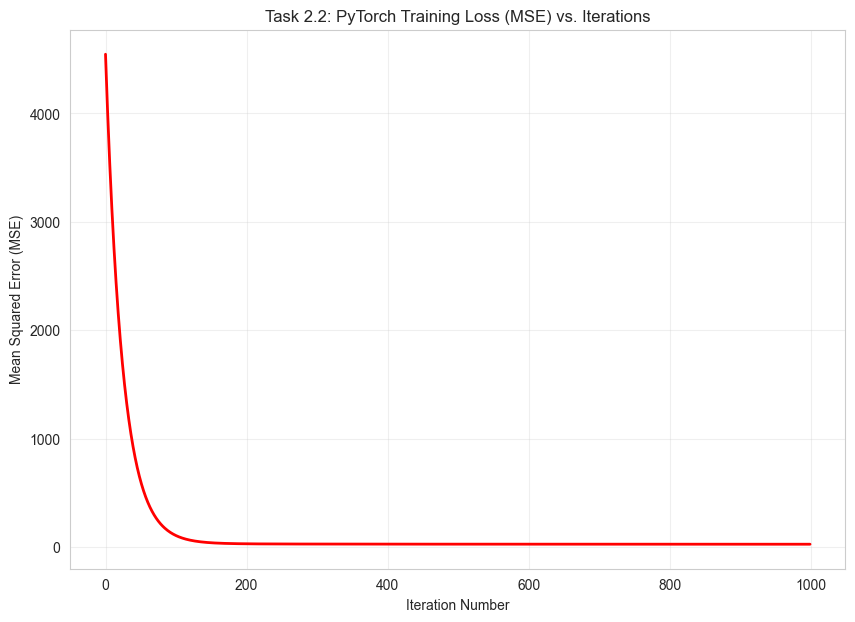

In [7]:
x_tensor = torch.from_numpy(train_z_score.values).float()
y_tensor = torch.from_numpy(y.values).float().view(-1, 1)

input_dim = x_tensor.shape[1]
model = nn.Linear(input_dim, 1)

learning_rate = 0.01
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
iterations = 1000
torch_loss_history = []

for i in range(iterations):
    y_prediction = model(x_tensor)

    loss = criterion(y_prediction, y_tensor)
    torch_loss_history.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

torch_weights = model.weight.data.numpy()
torch_bias = model.bias.data.numpy()
print("\nFinal Weights from PyTorch Model:")
print(torch_weights)
print("\nFinal Bias from PyTorch Model:")
print(torch_bias)

comparison = {
    "Parameter": ["Weight 1", "Weight 2", "Weight 3", "Weight 4", "Bias", "Final MSE"],
    "NumPy (Manual)": list(weights) + [bias, loss_history[-1]],
    "PyTorch": list(torch_weights.flatten()) + [torch_bias[0], torch_loss_history[-1]]
}
comparison = pd.DataFrame(comparison)
display(comparison)

# Plot Loss Curve
plt.figure(figsize=(10, 7))
plt.plot(torch_loss_history, color='red', linewidth=2)
plt.title('Task 2.2: PyTorch Training Loss (MSE) vs. Iterations')
plt.xlabel('Iteration Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, alpha=0.3)
plt.show()


Comparion:
The learned parameters produced very similar results between the NumPy and PyTorch implementations. Moreover, the NumPy and PyTorch implementations produced the same final MSE, meaning that both results and models were consistent. 

## 2.3 Polynomial Regression


The code below implements a polynomial regression model using PyTorch.


Polynomial Regression MSE Results:


,Degree,Train MSE,Test MSE
0,2,999.059692,992.573914
1,3,952.929993,1066.005615
2,5,815.477173,1100.019531
3,10,439.150269,32121.144531


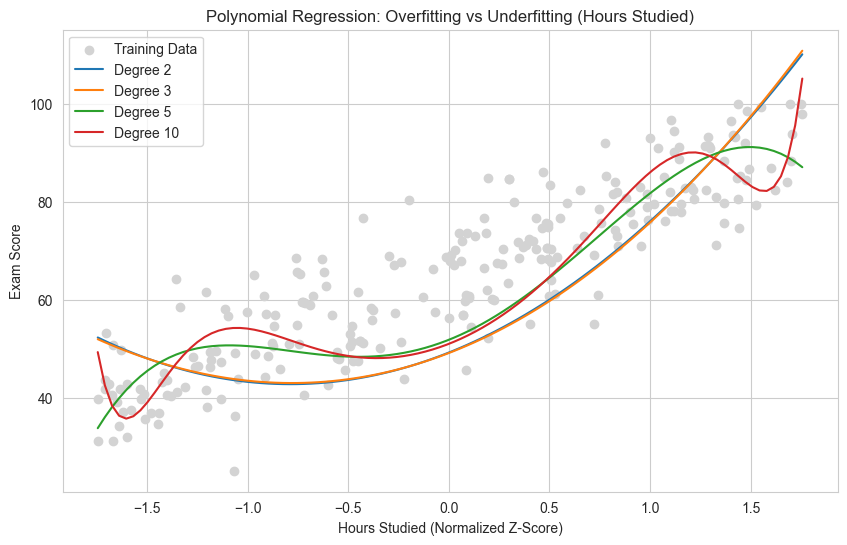

In [8]:
degrees = [2, 3, 5, 10]
mse_results = []


for d in degrees:

    # Transforms features to polynomial features
    poly = PolynomialFeatures(degree = d, include_bias=False)
    x_train_poly = poly.fit_transform(train_z_score)
    x_test_poly = poly.transform(x_test_normalized)

    # Converts to PyTorch tensors
    x_train_tensor = torch.tensor(x_train_poly, dtype=torch.float32)
    y_train_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)
    x_test_tensor = torch.tensor(x_test_poly, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

    model = nn.Linear(x_train_tensor.shape[1], 1)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    #Trains the model
    # iterations = 1000
    for i in range(iterations):
        pred = model(x_train_tensor)
        loss = criterion(pred, y_train_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        train_mse = criterion(model(x_train_tensor), y_train_tensor).item()
        test_mse = criterion(model(x_test_tensor), y_test_tensor).item()

    mse_results.append({'Degree': d, 'Train MSE': train_mse, 'Test MSE': test_mse})

print("\nPolynomial Regression MSE Results:")
display(pd.DataFrame(mse_results))


# Code to plot graph
plt.figure(figsize=(10, 6))

# Grab just the 'hours_studied' column (assuming it's the 0th index in your selected_features)
x_train_single = train_z_score['hours_studied'].values.reshape(-1, 1)
plt.scatter(x_train_single, y.values, color='lightgray', label='Training Data')

# Create a smooth line of x-values for plotting
x_range = np.linspace(x_train_single.min(), x_train_single.max(), 100).reshape(-1, 1)

for d in degrees:
    # Train a quick model just on the single feature so we can draw the 2D curve
    poly_single = PolynomialFeatures(degree=d, include_bias=False)
    X_poly_single = poly_single.fit_transform(x_train_single)
    X_range_poly = poly_single.transform(x_range)
    
    model_single = nn.Linear(X_poly_single.shape[1], 1)
    optimizer_single = torch.optim.Adam(model_single.parameters(), lr=0.1)
    
    X_t = torch.tensor(X_poly_single, dtype=torch.float32)
    y_t = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)
    
    for _ in range(1000):
        loss = criterion(model_single(X_t), y_t)
        optimizer_single.zero_grad()
        loss.backward()
        optimizer_single.step()
        
    with torch.no_grad():
        y_range_pred = model_single(torch.tensor(X_range_poly, dtype=torch.float32)).numpy()
        plt.plot(x_range, y_range_pred, label=f'Degree {d}')

plt.title('Polynomial Regression: Overfitting vs Underfitting (Hours Studied)')
plt.xlabel('Hours Studied (Normalized Z-Score)')
plt.ylabel('Exam Score')
plt.legend()
plt.show()




Analysis:
The different degrees create different lines, some of which are better fitted while some are over/underfitting. For example, degree 10 and 5 caused an overfitting line, as it dramatically increases and decreases. Degree 2 and degree 3 fit the data more accurately, and did not lead to underfitting. 

# 3. Logistic Regression


## 3.1 NumPy Implementation


r4


Logistic Regression Accuracy:
Training Accuracy: 0.8735
Testing Accuracy: 0.8625


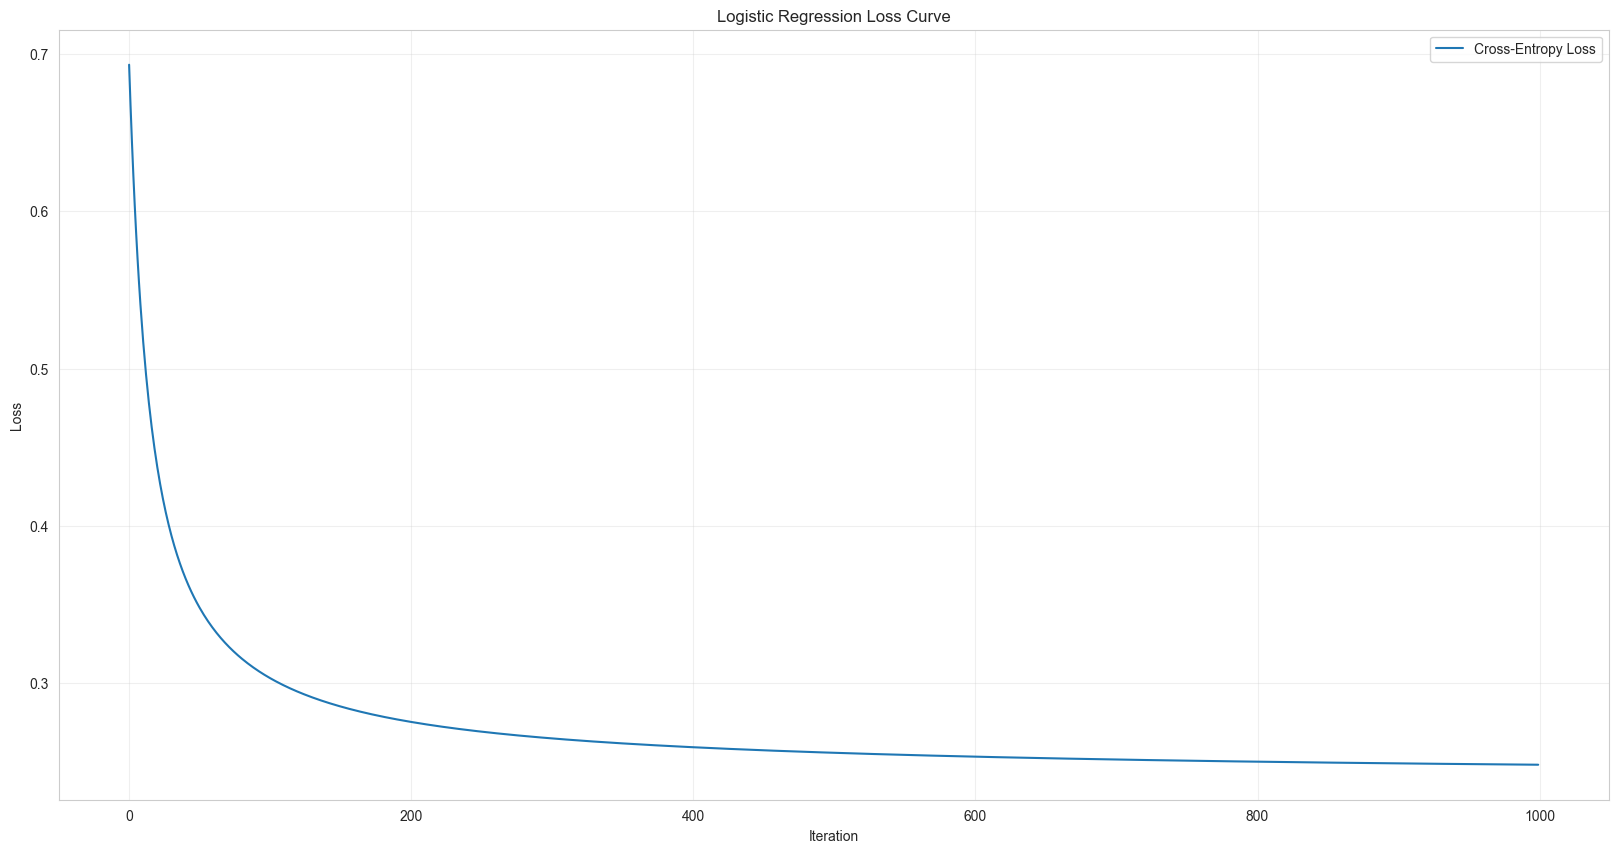

In [9]:
x_train = train_z_score.values
y_train = train['passed'].values

x_test_lr = x_test_normalized.values
y_test_lr = test['passed'].values

# Calculates Sigmoid Function
def sigmoid_func(z):
    return 1 / (1 + np.exp(-z))

features = x_train.shape[1]
weights = np.zeros(features)
bias = 0.0
learning_rate = 0.1
iterations = 1000
loss_history = []
for i in range(iterations):
    z = np.dot(x_train, weights) + bias
    y_hat = sigmoid_func(z)

    # Calculates Cross-Entropy Loss
    # Epsilong to prevent log(0)
    epsilon = 1e-15
    loss = -np.mean(y_train * np.log(y_hat + epsilon) + (1 - y_train) * np.log(1 - y_hat + epsilon))
    loss_history.append(loss)

    # Compute Gradients
    error = y_hat - y_train
    gradient_1 = np.dot(x_train.T, error) / len(y_train)
    gradient_2 = np.sum(error) / len(y_train)
    
    # Update weights and bias
    weights -= learning_rate * gradient_1
    bias -= learning_rate * gradient_2

# Check Accuracy

train_predictions = (sigmoid_func(np.dot(x_train, weights) + bias) >= 0.5).astype(int)
train_accuracy = np.mean(train_predictions == y_train)

test_predictions = (sigmoid_func(np.dot(x_test_lr, weights) + bias) >= 0.5).astype(int)
test_accuracy = np.mean(test_predictions == y_test_lr)
print("\nLogistic Regression Accuracy:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# Plot Loss Curve
plt.figure(figsize=(20,10))
plt.plot(loss_history, label='Cross-Entropy Loss')
plt.title('Logistic Regression Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

    

## 3.2 PyTorch Verification


The following code will implement logistic regression using PyTorch.

In [10]:
# Converts to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
x_test_tensor = torch.tensor(x_test_lr, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_lr, dtype=torch.float32).view(-1, 1)

# Defines Logistic Regression Model

input_dim = x_train_tensor.shape[1]
model_lr = nn.Linear(input_dim, 1)

criterion_lr = nn.BCEWithLogitsLoss()
optimizer_lr = torch.optim.Adam(model_lr.parameters(), lr=0.1)

iterations = 1000
torch_loss_history = []
for i in range(iterations):
    logits = model_lr(x_train_tensor)
    # Calculate loss
    loss = criterion_lr(logits, y_train_tensor)
    torch_loss_history.append(loss.item())
    optimizer_lr.zero_grad()
    loss.backward()
    optimizer_lr.step()

# Check Accuracies
with torch.no_grad():
    train_probability = torch.sigmoid(model_lr(x_train_tensor))
    train_pred = (train_probability >= 0.5).float()
    train_accuracy_torch = (train_pred == y_train_tensor).float().mean().item()
    
    test_probability = torch.sigmoid(model_lr(x_test_tensor))
    test_pred = (test_probability >= 0.5).float()
    test_accuracy_torch = (test_pred == y_test_tensor).float().mean().item()

torch_weights = model_lr.weight.detach().numpy().flatten()
torch_bias = model_lr.bias.detach().numpy()[0]
print("\nFinal Weights from PyTorch Logistic Regression Model:")
print(torch_weights)
print("\nFinal Bias from PyTorch Logistic Regression Model:")
print(torch_bias)
print("\nLogistic Regression Accuracy Comparison:")
accuracy_comparison = {
    "Metric": ["Training Accuracy", "Testing Accuracy"],
    "NumPy (Manual)": [train_accuracy, test_accuracy],
    "PyTorch": [train_accuracy_torch, test_accuracy_torch]
}
accuracy_comparison = pd.DataFrame(accuracy_comparison)
display(accuracy_comparison)


Final Weights from PyTorch Logistic Regression Model:
[3.553865   1.1132876  1.1546123  0.24300367]

Final Bias from PyTorch Logistic Regression Model:
1.0739208

Logistic Regression Accuracy Comparison:


,Metric,NumPy (Manual),PyTorch
0,Training Accuracy,0.873469,0.873469
1,Testing Accuracy,0.862500,0.862500


## 3.3 Analysis & Visualization


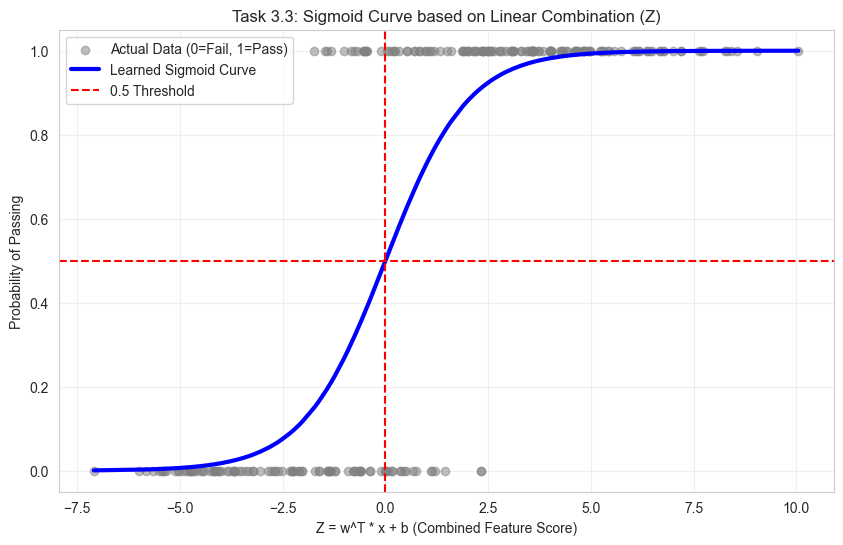

--- Threshold Experiment ---
Accuracy at Threshold 0.3: 86.12%
Accuracy at Threshold 0.5: 87.35%
Accuracy at Threshold 0.7: 86.53%


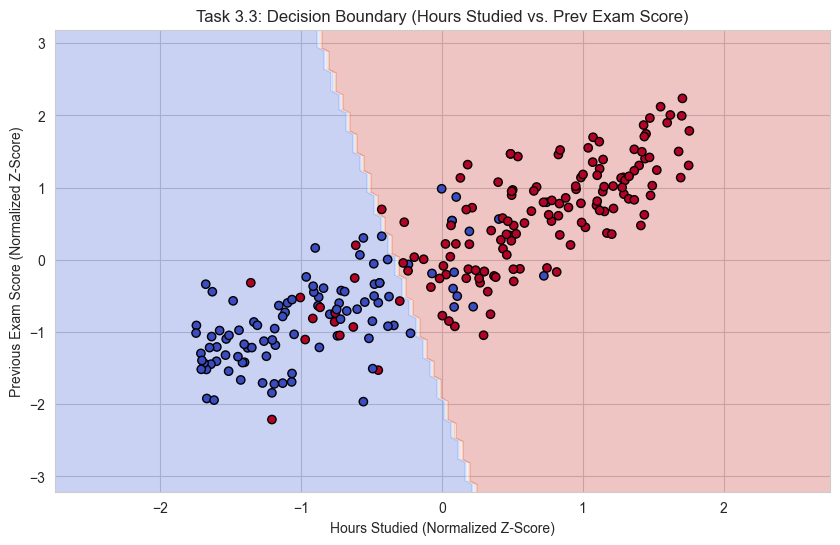

In [11]:
# Calculate the linear combination (z) for all training points
z_values = np.dot(x_train, weights) + bias
probabilities = sigmoid_func(z_values)

# Sort values for a smooth curve plot
sorted_indices = np.argsort(z_values)
z_sorted = z_values[sorted_indices]
prob_sorted = probabilities[sorted_indices]

plt.figure(figsize=(10, 6))
# Plot actual data points (0 or 1)
plt.scatter(z_values, y_train, color='gray', alpha=0.5, label='Actual Data (0=Fail, 1=Pass)')
# Plot the learned sigmoid curve
plt.plot(z_sorted, prob_sorted, color='blue', linewidth=3, label='Learned Sigmoid Curve')
# Draw the standard 0.5 decision threshold
plt.axhline(0.5, color='red', linestyle='--', label='0.5 Threshold')
plt.axvline(0, color='red', linestyle='--')

plt.title('Task 3.3: Sigmoid Curve based on Linear Combination (Z)')
plt.xlabel('Z = w^T * x + b (Combined Feature Score)')
plt.ylabel('Probability of Passing')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- 2. Threshold Experiment ---
# Experimenting with different thresholds as required by the rubric
thresholds = [0.3, 0.5, 0.7]
print("--- Threshold Experiment ---")
for t in thresholds:
    preds = (probabilities >= t).astype(int)
    acc = np.mean(preds == y_train) * 100
    print(f"Accuracy at Threshold {t}: {acc:.2f}%")

# --- 3. Decision Boundary (2 Features for Visualization) ---
# We use the two strongest features: hours_studied (idx 0) and prev_exam_score (idx 3)
x_2d = x_train[:, [0, 3]]
w_2d = np.zeros(2)
b_2d = 0.0

# Train a quick 2D model
for _ in range(1000):
    p_2d = sigmoid_func(np.dot(x_2d, w_2d) + b_2d)
    error_2d = p_2d - y_train
    w_2d -= 0.1 * (np.dot(x_2d.T, error_2d) / len(y_train))
    b_2d -= 0.1 * (np.sum(error_2d) / len(y_train))

# Create a mesh grid to draw the boundary
x_min, x_max = x_2d[:, 0].min() - 1, x_2d[:, 0].max() + 1
y_min, y_max = x_2d[:, 1].min() - 1, x_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

# Predict across the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_preds = (sigmoid_func(np.dot(grid_points, w_2d) + b_2d) >= 0.5).astype(int).reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, grid_preds, alpha=0.3, cmap='coolwarm')
plt.scatter(x_2d[:, 0], x_2d[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title('Task 3.3: Decision Boundary (Hours Studied vs. Prev Exam Score)')
plt.xlabel('Hours Studied (Normalized Z-Score)')
plt.ylabel('Previous Exam Score (Normalized Z-Score)')
plt.show()

# 4. Summary & Reflection


The preprocessing step that had the biggest impact on model performance was dropping duplicated, missing and impossible. If these values stayed in the training data set, the model would perform poorly against the test data set. As a result, data cleaning was an important step in the preprocessing steps. Moreover, removing outliers prevented the skewing of the training data. The NumPy and PyTorch implementations performed incredibly similarly. These results gave me more confidence that the models were being developed properly and correctly. Developing the implementation from scratch taught me much more than using a library would have because it helped me apply the formulas and concepts discussed in the lectures into actual code. Moreover, developing from scratch also led to a higher rate of mutability. Each part of the code could be tweaked and changed to achieve more accurate or different results. The most challenging part of this project was the EDA and preprocessing. This difficulty was rooted in the fact that I had to decide between data imputation and dropping data. I had to review the lecture notes to check when it was correct to impute the data or drop it entirely. For this project, I decided to drop the data since it did not appear to be a meaningful number of rows, especially since there were several hundred more that the model could be trained off of. If I had more time, I would try different pre-processing steps. These steps would include data imputation. Different models would be trained with different data imputation methods, such as using the mean, median, mode, and seeing how it compares to the original implementation. Since the original implementation dropped these rows, I would assume that the results would slightly differ, but would give me more insight into when each data imputation method could be used. 